## Human in the Loop

In [ ]:
from typing import Annotated, TypedDict
from langchain_openai import ChatOpenAI
from langchain_core.messages import AnyMessage, AIMessage

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages # Reducers in langGraph are used to process and transform messages as they flow through the graph.
from dotenv import load_dotenv
import os
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt , Command
from langchain_core.messages import BaseMessage

In [3]:
load_dotenv()

True

In [ ]:
llm = ChatOpenAI(model="gpt-3.5-turbo", temperature=0.9)

In [5]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]
    

In [ ]:
def chat_node(state:ChatState):
    decision = interrupt({ # Interrupt is used to pause the execution of the graph and wait for a decision from the user before proceeding.
        "type": "approval",
        "reason":"model is about to answer a user's question",
        "question": state["messages"][-1].content,
        "instructions":"Approve this question? yes/no"
    })

    if decision["approved"] =='no':
        return{"messages":[AIMessage(content="Your question was not approved by the human in the loop. Please try again with a different question.")]}
    
    else :
        response = llm.invoke(state["messages"])
        return {"messages":[response]}

In [ ]:
# Build the graph
builder = StateGraph(ChatState)
builder.add_node("chat",chat_node)
builder.add_edge(START,"chat")
builder.add_edge("chat",END)
checkpointer = MemorySaver() # important to save the conversation because of human in loop 
app = builder.compile(checkpointer=checkpointer) # checkpointer means the state of the graph will be saved at each step, allowing us to resume from the last checkpoint in case of an interruption or failure.


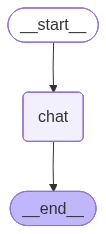

In [10]:
app

In [ ]:
# Create a new thread for this conversation
config = {"configurable":{"thread_id": "1"}} # thread_id is used to identify the conversation thread in the memory.

# Step 1 : User asks a question
initial_input = {
    "messages":[
        {"role": "user", "content": "Explain gradient descent in simple terms"}
    ]
}

result = app.invoke(initial_input, config=config)
result

{'messages': [HumanMessage(content='Explain gradient descent in simple terms', additional_kwargs={}, response_metadata={}, id='b0413155-d541-4562-9d39-e04d910ec0f5')],
 '__interrupt__': [Interrupt(value={'type': 'approval', 'reason': "model is about to answera user's question", 'question': 'Explain gradient descent in simple terms', 'instructions': 'Approve this question? yes/no'}, id='6c8b507d18ab05c36029cc8ff3933b67')]}

In [16]:
message = result["__interrupt__"][0].value
message

{'type': 'approval',
 'reason': "model is about to answera user's question",
 'question': 'Explain gradient descent in simple terms',
 'instructions': 'Approve this question? yes/no'}

In [17]:
user_input = input("Backend message {message}. Do you approve this question? (yes/no): ")

In [18]:
final_result = app.invoke(
    Command(resume={"approved": user_input},
            config = config,)
)

TypeError: Command.__init__() got an unexpected keyword argument 'config'